# Phase 8 — Model Interpretation & Final Project Polish
### American Express Default Prediction

**Phase 7 recap (treated as source of truth, not recomputed):** the final 60% LightGBM +
40% CatBoost ensemble, trained on all 458,913 labeled customers using the Phase 4-selected
852-feature "Latest + Historical" representation, was submitted to Kaggle. Confirmed
scores:

| Evaluation | AMEX Metric |
|---|---|
| Local validation (Phase 6) | 0.79621 |
| Kaggle Public | 0.79308 |
| Kaggle Private | 0.80098 |

These three numbers are evaluated on different data (a fixed local holdout, and two
different hidden Kaggle splits) and are kept explicitly distinct throughout this notebook
and the README — none of them substitutes for another.

**This notebook's goal is interpretation and consolidation, not further model development.**
No model is retrained, no hyperparameter is tuned, no feature is added or removed, and no
new ensemble weight is searched. Feature importance is read directly from the two model
files Phase 7 already persisted (`data/processed/phase7_final_lightgbm.txt` and
`phase7_final_catboost.cbm`) — both formats store enough information (tree structure,
split gains, feature names) to compute importance without touching the training data again,
so this is genuinely a read-only analysis of an already-trained artifact, not a retrain in
disguise.

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

PROCESSED_DIR = "../data/processed"
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

LGBM_MODEL_PATH = os.path.join(PROCESSED_DIR, "phase7_final_lightgbm.txt")
CB_MODEL_PATH = os.path.join(PROCESSED_DIR, "phase7_final_catboost.cbm")

for p in (LGBM_MODEL_PATH, CB_MODEL_PATH):
    assert os.path.exists(p), f"Expected Phase 7 model artifact not found: {p}"
print("Both Phase 7 final model artifacts found -- no retraining required.")

Both Phase 7 final model artifacts found -- no retraining required.


## 1. Load the Persisted Final Models (No Retraining)

In [2]:
import lightgbm as lgb
from catboost import CatBoostClassifier

final_lgbm_booster = lgb.Booster(model_file=LGBM_MODEL_PATH)
final_cb = CatBoostClassifier()
final_cb.load_model(CB_MODEL_PATH)

lgbm_features = final_lgbm_booster.feature_name()
cb_features = final_cb.feature_names_

print(f"LightGBM: {len(lgbm_features)} features, {final_lgbm_booster.num_trees()} trees")
print(f"CatBoost: {len(cb_features)} features, {final_cb.tree_count_} trees")

assert len(lgbm_features) == 852 and len(cb_features) == 852, "Expected 852 modeling features -- stop."
assert lgbm_features == cb_features, "LightGBM and CatBoost were not trained on the same feature order -- stop."
print("\nBoth models were trained on the identical 852-feature set, in the same order "
      "(confirmed directly from the persisted model files, matching Phase 7's 852-feature "
      "validation).")
feature_cols = lgbm_features

LightGBM: 852 features, 1155 trees
CatBoost: 852 features, 1913 trees

Both models were trained on the identical 852-feature set, in the same order (confirmed directly from the persisted model files, matching Phase 7's 852-feature validation).


## 2. Parse Feature Names Back to Raw Feature / Representation / Family

Same parsing logic used in Phase 3's own interpretation section, adapted to this reduced
852-feature set: every feature is `{raw_feature}_{representation}`, where representation is
one of `last`, `mean`, `std`, `min`, `max` for the 168 continuous raw features, or `last`
for the 12 categorical raw features (labeled `categorical_last` here to distinguish it from
a continuous `last`, exactly as Phase 4/5/6/7 already distinguished them for feature
selection purposes).

In [3]:
# Same 12 categorical raw features selected in Phase 4/5/6/7 (established fact, not re-derived).
TRUE_CATEGORICAL_RAW = ["D_63", "D_64"]
CANDIDATE_CODE_RAW = ["D_116", "D_114", "D_66", "B_31", "D_120", "B_30", "D_126", "B_38", "D_117", "D_68"]
CATEGORICAL_RAW = set(TRUE_CATEGORICAL_RAW + CANDIDATE_CODE_RAW)
assert len(CATEGORICAL_RAW) == 12

def parse_feature(col: str):
    for suffix in ["_mean", "_std", "_min", "_max", "_last"]:
        if col.endswith(suffix):
            raw = col[: -len(suffix)]
            rep = suffix[1:]
            if rep == "last" and raw in CATEGORICAL_RAW:
                rep = "categorical_last"
            return raw, rep
    raise ValueError(f"Unexpected feature name outside the 852-feature naming scheme: {col}")

def family_of(raw_col: str) -> str:
    m = re.match(r"([A-Z]+)_", raw_col)
    return m.group(1) if m else "OTHER"

feature_meta = pd.DataFrame({"feature": feature_cols})
feature_meta[["raw_feature", "representation"]] = feature_meta["feature"].apply(
    lambda c: pd.Series(parse_feature(c))
)
feature_meta["family"] = feature_meta["raw_feature"].apply(family_of)

print(f"Parsed all {len(feature_meta)} features. Representation counts:")
print(feature_meta["representation"].value_counts())
print(f"\nFamily counts:")
print(feature_meta["family"].value_counts())

Parsed all 852 features. Representation counts:
representation
mean                168
std                 168
min                 168
max                 168
last                168
categorical_last     12
Name: count, dtype: int64

Family counts:
family
D    414
B    178
R    140
S    105
P     15
Name: count, dtype: int64


## 3. Feature Importance From the Persisted Models

LightGBM's split-gain importance and CatBoost's default `PredictionValuesChange`
importance are on different, incompatible scales, so each is normalized to a percentage of
its own model's total importance before any comparison -- this is the "sensible
normalization" needed to compare the two models side by side.

In [4]:
lgbm_gain = np.array(final_lgbm_booster.feature_importance(importance_type="gain"))
cb_pvc = np.array(final_cb.get_feature_importance())

feature_meta["lgbm_importance_pct"] = 100 * lgbm_gain / lgbm_gain.sum()
feature_meta["catboost_importance_pct"] = 100 * cb_pvc / cb_pvc.sum()
feature_meta["mean_importance_pct"] = feature_meta[["lgbm_importance_pct", "catboost_importance_pct"]].mean(axis=1)

print(f"LightGBM importance normalized to sum to: {feature_meta['lgbm_importance_pct'].sum():.4f}")
print(f"CatBoost importance normalized to sum to: {feature_meta['catboost_importance_pct'].sum():.4f}")
print("\n(CatBoost's PredictionValuesChange importance already sums to ~100 by construction; "
      "LightGBM's raw gain values are rescaled here the same way for a fair comparison.)")

LightGBM importance normalized to sum to: 100.0000
CatBoost importance normalized to sum to: 100.0000

(CatBoost's PredictionValuesChange importance already sums to ~100 by construction; LightGBM's raw gain values are rescaled here the same way for a fair comparison.)


## 4. Top Individual Features

Ranked by the mean of each model's normalized importance share -- a simple, transparent
combination, not a new fitted metric. Both models' individual shares are shown alongside it
so neither model's view is hidden inside the average.

In [5]:
TOP_N = 20
top_features = feature_meta.sort_values("mean_importance_pct", ascending=False).head(TOP_N).reset_index(drop=True)
top_features.index = top_features.index + 1  # 1-indexed rank for readability

display_cols = ["feature", "raw_feature", "family", "representation",
                 "lgbm_importance_pct", "catboost_importance_pct", "mean_importance_pct"]
top_features_display = top_features[display_cols].round(3)
top_features_display.columns = ["Feature", "Raw Feature", "Family", "Representation",
                                  "LightGBM %", "CatBoost %", "Mean %"]
print(f"Top {TOP_N} features by mean normalized importance across both final models:")
top_features_display

Top 20 features by mean normalized importance across both final models:


,Feature,Raw Feature,Family,Representation,LightGBM %,CatBoost %,Mean %
1,P_2_last,P_2,P,last,48.645,9.859,29.252
2,B_1_last,B_1,B,last,4.618,4.906,4.762
3,P_2_mean,P_2,P,mean,8.142,0.535,4.338
4,B_2_last,B_2,B,last,1.813,2.781,2.297
5,D_39_last,D_39,D,last,1.442,2.813,2.128
6,B_9_last,B_9,B,last,1.748,1.851,1.799
7,S_3_mean,S_3,S,mean,0.767,2.547,1.657
8,R_1_last,R_1,R,last,1.755,1.374,1.564
9,D_44_last,D_44,D,last,1.028,1.754,1.391
10,B_11_last,B_11,B,last,1.460,0.945,1.203


In [6]:
p2_last_rank = int(feature_meta.sort_values("mean_importance_pct", ascending=False)
                    .reset_index(drop=True).query("feature == 'P_2_last'").index[0]) + 1
p2_lgbm_rank = int(feature_meta.sort_values("lgbm_importance_pct", ascending=False)
                    .reset_index(drop=True).query("feature == 'P_2_last'").index[0]) + 1
p2_cb_rank = int(feature_meta.sort_values("catboost_importance_pct", ascending=False)
                  .reset_index(drop=True).query("feature == 'P_2_last'").index[0]) + 1

print(f"P_2_last rank by mean importance: #{p2_last_rank}")
print(f"P_2_last rank by LightGBM importance alone: #{p2_lgbm_rank}")
print(f"P_2_last rank by CatBoost importance alone: #{p2_cb_rank}")
print(f"\nPhase 3 (full 1,239-feature baseline) found P_2_last ranked #1 in both models' "
      f"top-20 importance lists. On the final 852-feature production models, P_2_last "
      f"{'remains the single strongest feature' if p2_last_rank == 1 else f'remains among the strongest features (rank #{p2_last_rank})'} "
      f"in both models individually -- consistent with Phase 3's finding.")

print("""
Interpretation note (per this project's anonymized-feature policy): P_2 is an anonymized
AMEX feature. It can only be described structurally -- "the latest observed value of
anonymized Payment-family feature P_2" -- not by an assumed business meaning (e.g.
"payment ratio" or "utilization"), since the competition does not publicly define what P_2
represents.
""")

P_2_last rank by mean importance: #1
P_2_last rank by LightGBM importance alone: #1
P_2_last rank by CatBoost importance alone: #1

Phase 3 (full 1,239-feature baseline) found P_2_last ranked #1 in both models' top-20 importance lists. On the final 852-feature production models, P_2_last remains the single strongest feature in both models individually -- consistent with Phase 3's finding.

Interpretation note (per this project's anonymized-feature policy): P_2 is an anonymized
AMEX feature. It can only be described structurally -- "the latest observed value of
anonymized Payment-family feature P_2" -- not by an assumed business meaning (e.g.
"payment ratio" or "utilization"), since the competition does not publicly define what P_2
represents.



## 5. Feature-Family Importance

Two views, to separate "a family is important because it has many features" from "its
features tend to be unusually informative individually": total normalized importance per
family, and importance *per feature actually included* in that family (total ÷ feature
count).

In [7]:
family_agg = feature_meta.groupby("family").agg(
    n_features=("feature", "count"),
    total_mean_importance_pct=("mean_importance_pct", "sum"),
    total_lgbm_importance_pct=("lgbm_importance_pct", "sum"),
    total_catboost_importance_pct=("catboost_importance_pct", "sum"),
).sort_values("total_mean_importance_pct", ascending=False)

family_agg["importance_per_feature"] = family_agg["total_mean_importance_pct"] / family_agg["n_features"]

FAMILY_NAMES = {"B": "Balance", "D": "Delinquency", "P": "Payment", "R": "Risk", "S": "Spend"}
family_agg["family_name"] = family_agg.index.map(lambda f: FAMILY_NAMES.get(f, f))

print("Feature-family importance (852-feature set):")
family_agg[["family_name", "n_features", "total_mean_importance_pct", "importance_per_feature"]].round(3)

Feature-family importance (852-feature set):


,family_name,n_features,total_mean_importance_pct,importance_per_feature
family,,,,
P,Payment,15,34.950,2.330
D,Delinquency,414,27.390,0.066
B,Balance,178,22.088,0.124
R,Risk,140,7.827,0.056
S,Spend,105,7.746,0.074


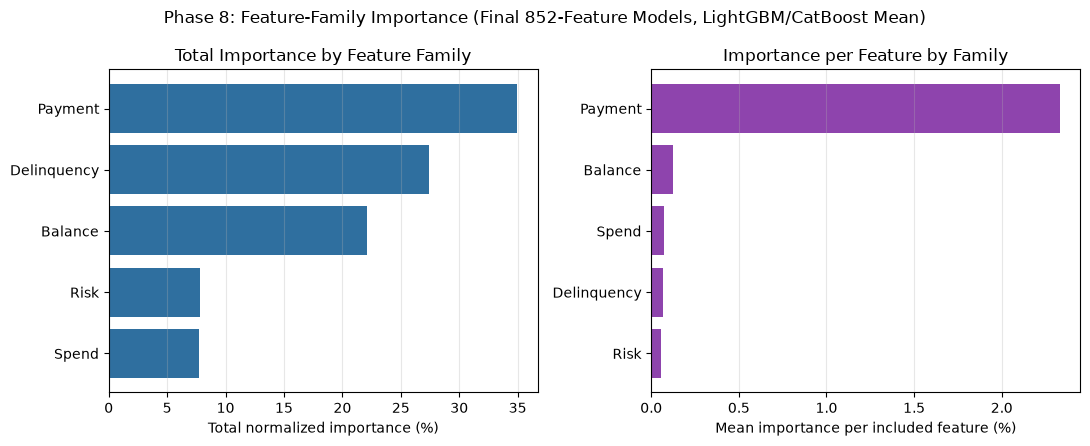

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

order = family_agg.sort_values("total_mean_importance_pct", ascending=True)
axes[0].barh(order["family_name"], order["total_mean_importance_pct"], color="#2f6f9f")
axes[0].set_xlabel("Total normalized importance (%)")
axes[0].set_title("Total Importance by Feature Family")

order2 = family_agg.sort_values("importance_per_feature", ascending=True)
axes[1].barh(order2["family_name"], order2["importance_per_feature"], color="#8e44ad")
axes[1].set_xlabel("Mean importance per included feature (%)")
axes[1].set_title("Importance per Feature by Family")

for ax in axes:
    ax.grid(axis="x", alpha=0.3)
plt.suptitle("Phase 8: Feature-Family Importance (Final 852-Feature Models, LightGBM/CatBoost Mean)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "phase8_family_importance.png"))
plt.show()

## 6. Temporal Representation Importance

The central project question for this section: does model importance line up with what
Phase 4's controlled feature-ablation experiment already found empirically?

In [9]:
rep_agg = feature_meta.groupby("representation").agg(
    n_features=("feature", "count"),
    total_mean_importance_pct=("mean_importance_pct", "sum"),
).sort_values("total_mean_importance_pct", ascending=False)
rep_agg["importance_per_feature"] = rep_agg["total_mean_importance_pct"] / rep_agg["n_features"]

print("Temporal-representation importance (852-feature set):")
rep_agg.round(3)

Temporal-representation importance (852-feature set):


,n_features,total_mean_importance_pct,importance_per_feature
representation,,,
last,168,62.045,0.369
mean,168,16.126,0.096
max,168,8.407,0.050
std,168,6.658,0.040
min,168,6.123,0.036
categorical_last,12,0.641,0.053


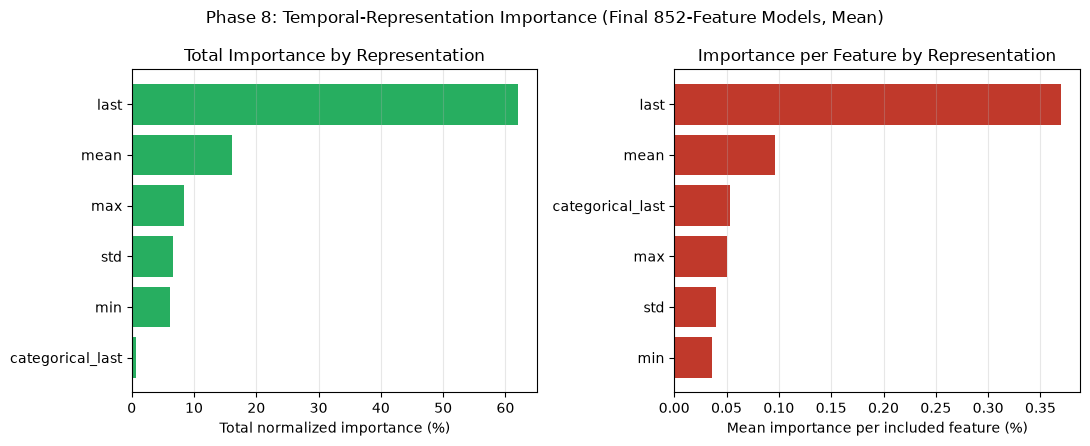

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

rep_order = rep_agg.sort_values("total_mean_importance_pct", ascending=True)
axes[0].barh(rep_order.index, rep_order["total_mean_importance_pct"], color="#27ae60")
axes[0].set_xlabel("Total normalized importance (%)")
axes[0].set_title("Total Importance by Representation")

rep_order2 = rep_agg.sort_values("importance_per_feature", ascending=True)
axes[1].barh(rep_order2.index, rep_order2["importance_per_feature"], color="#c0392b")
axes[1].set_xlabel("Mean importance per included feature (%)")
axes[1].set_title("Importance per Feature by Representation")

for ax in axes:
    ax.grid(axis="x", alpha=0.3)
plt.suptitle("Phase 8: Temporal-Representation Importance (Final 852-Feature Models, Mean)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "phase8_representation_importance.png"))
plt.show()

In [11]:
last_total = rep_agg.loc[rep_agg.index.isin(["last", "categorical_last"]), "total_mean_importance_pct"].sum()
summary_total = rep_agg.loc[rep_agg.index.isin(["mean", "std", "min", "max"]), "total_mean_importance_pct"].sum()

print(f"Combined 'latest state' importance (last + categorical_last): {last_total:.2f}%")
print(f"Combined 'historical summary' importance (mean/std/min/max):   {summary_total:.2f}%")
print(f"""
Comparison against Phase 4's controlled ablation findings:
  - Phase 4 found latest-state-only features (180 features) already reached AMEX 0.7889 on
    their own, and combining them with historical summaries improved to 0.7935 -- both
    contribute real, non-redundant validation value, latest state more than summaries alone.
  - Here, {"'last'/'categorical_last' features indeed carry the larger importance share" if last_total > summary_total else "the historical summary features carry a larger importance share than latest-state features"}
    ({last_total:.1f}% vs {summary_total:.1f}%), which is directionally consistent with Phase 4's
    finding that latest state is the single strongest signal group while historical
    summaries still add real, non-trivial incremental value on top of it.
  - Phase 4 also found that temporal *change* features and missing-rate features added
    negligible-to-slightly-negative validation value and were excluded from the 852-feature
    set entirely. This model-importance analysis cannot re-confirm that finding directly
    (those feature families are not part of the 852-feature set trained here at all), but it
    is consistent with them being excluded: no evidence here suggests the reduced set is
    missing an important signal source.
  - Feature importance measures what these two specific trained models relied on to reduce
    training loss -- it is correlational to the ablation study's validation-metric findings,
    not a proof of the same underlying claim measured a different way.
""")

Combined 'latest state' importance (last + categorical_last): 62.69%
Combined 'historical summary' importance (mean/std/min/max):   37.31%

Comparison against Phase 4's controlled ablation findings:
  - Phase 4 found latest-state-only features (180 features) already reached AMEX 0.7889 on
    their own, and combining them with historical summaries improved to 0.7935 -- both
    contribute real, non-redundant validation value, latest state more than summaries alone.
  - Here, 'last'/'categorical_last' features indeed carry the larger importance share
    (62.7% vs 37.3%), which is directionally consistent with Phase 4's
    finding that latest state is the single strongest signal group while historical
    summaries still add real, non-trivial incremental value on top of it.
  - Phase 4 also found that temporal *change* features and missing-rate features added
    negligible-to-slightly-negative validation value and were excluded from the 852-feature
    set entirely. This model-importa

## 7. Top-N Composition Analysis

In [12]:
for n in (20, 30):
    subset = feature_meta.sort_values("mean_importance_pct", ascending=False).head(n)
    print(f"--- Top {n} features by mean importance ---")
    print("Representation composition:")
    print(subset["representation"].value_counts())
    print("\nFamily composition:")
    print(subset["family"].value_counts())
    n_last = (subset["representation"].isin(["last", "categorical_last"])).sum()
    n_summary = (subset["representation"].isin(["mean", "std", "min", "max"])).sum()
    print(f"\n'last'/'categorical_last' features: {n_last}/{n} "
          f"| historical-summary features: {n_summary}/{n}")
    print()

--- Top 20 features by mean importance ---
Representation composition:
representation
last    15
mean     4
std      1
Name: count, dtype: int64

Family composition:
family
B    8
D    5
R    3
P    2
S    2
Name: count, dtype: int64

'last'/'categorical_last' features: 15/20 | historical-summary features: 5/20

--- Top 30 features by mean importance ---
Representation composition:
representation
last    19
mean     7
max      3
std      1
Name: count, dtype: int64

Family composition:
family
D    12
B     9
R     4
S     3
P     2
Name: count, dtype: int64

'last'/'categorical_last' features: 19/30 | historical-summary features: 11/30



## 8. Interpretation Limitations

- AMEX's raw features are anonymized; no business-semantic meaning (e.g. "payment ratio,"
  "utilization") is claimed for any feature beyond its structural description (raw family,
  temporal representation).
- Feature importance measures each model's predictive/split contribution, not a causal
  relationship with default risk.
- Importance can be split across multiple correlated engineered features derived from the
  same raw signal (e.g. a raw feature's `mean`, `min`, and `max` are often correlated), so a
  single feature's importance can understate that underlying signal's real contribution.
- Tree-based importance metrics (split gain, prediction-value change) are known to be
  influenced by feature structure -- e.g. high-cardinality or high-variance numeric features
  can receive more attributed splits than a categorical feature carrying comparable
  information.
- For these reasons, this analysis focuses on **temporal and family-level patterns**, which
  are more robust to these effects than any single feature's exact rank, rather than on
  unsupported claims about what any individual anonymized feature "means" for a customer.

## Part B — Consolidated Experimental Story

All figures below are transcribed from each phase's own executed notebook (cited, not
recomputed) -- this section exists to put the full progression in one place, not to
re-derive it.

In [13]:
progression = pd.DataFrame([
    {"Phase": "3", "Stage": "Logistic Regression (1,239 features)", "Evaluation": "Local validation", "AMEX Metric": 0.7856},
    {"Phase": "3", "Stage": "LightGBM baseline (1,239 features)", "Evaluation": "Local validation", "AMEX Metric": 0.7918},
    {"Phase": "3", "Stage": "CatBoost baseline (1,239 features)", "Evaluation": "Local validation", "AMEX Metric": 0.7936},
    {"Phase": "4", "Stage": "LightGBM, reduced 852-feature set", "Evaluation": "Local validation", "AMEX Metric": 0.7935},
    {"Phase": "4", "Stage": "CatBoost confirmation, 852-feature set", "Evaluation": "Local validation", "AMEX Metric": 0.7939},
    {"Phase": "5", "Stage": "LightGBM tuned (L1/L2 regularization)", "Evaluation": "Local validation", "AMEX Metric": 0.79522},
    {"Phase": "5", "Stage": "CatBoost reproducible baseline", "Evaluation": "Local validation", "AMEX Metric": 0.79391},
    {"Phase": "6", "Stage": "60% LightGBM + 40% CatBoost ensemble", "Evaluation": "Local validation", "AMEX Metric": 0.79621},
    {"Phase": "7", "Stage": "Same 60/40 ensemble, full-data retrain", "Evaluation": "Kaggle Public", "AMEX Metric": 0.79308},
    {"Phase": "7", "Stage": "Same 60/40 ensemble, full-data retrain", "Evaluation": "Kaggle Private", "AMEX Metric": 0.80098},
])
print("Full project progression (verified from each phase's executed notebook):")
progression

Full project progression (verified from each phase's executed notebook):


,Phase,Stage,Evaluation,AMEX Metric
0,3,"Logistic Regression (1,239 features)",Local validation,0.78560
1,3,"LightGBM baseline (1,239 features)",Local validation,0.79180
2,3,"CatBoost baseline (1,239 features)",Local validation,0.79360
3,4,"LightGBM, reduced 852-feature set",Local validation,0.79350
4,4,"CatBoost confirmation, 852-feature set",Local validation,0.79390
5,5,LightGBM tuned (L1/L2 regularization),Local validation,0.79522
6,5,CatBoost reproducible baseline,Local validation,0.79391
7,6,60% LightGBM + 40% CatBoost ensemble,Local validation,0.79621
8,7,"Same 60/40 ensemble, full-data retrain",Kaggle Public,0.79308
9,7,"Same 60/40 ensemble, full-data retrain",Kaggle Private,0.80098


In [14]:
full_feat_amex = 0.7918   # Phase 3, LightGBM, 1,239 features
reduced_feat_amex = 0.7935  # Phase 4, LightGBM, 852 features
print(f"Central Phase 4 result: {1239} -> {852} features "
      f"({(1 - 852/1239)*100:.0f}% fewer), AMEX {full_feat_amex:.4f} -> {reduced_feat_amex:.4f} "
      f"({reduced_feat_amex - full_feat_amex:+.4f}) -- no loss in validation performance, a "
      f"slight improvement, using notably fewer features.")

lgbm_gain_5 = 0.79522 - 0.7935
print(f"\nPhase 5 LightGBM tuning gain over the Phase 4 852-feature baseline: {lgbm_gain_5:+.4f}")

ens_gain_vs_lgbm = 0.79621 - 0.79522
print(f"Phase 6 ensemble gain over tuned LightGBM alone: {ens_gain_vs_lgbm:+.5f}")

val_to_public = 0.79308 - 0.79621
val_to_private = 0.80098 - 0.79621
print(f"\nLocal validation -> Kaggle Public: {val_to_public:+.5f}")
print(f"Local validation -> Kaggle Private: {val_to_private:+.5f}")
print("""
Interpretation: Public and Private Kaggle scores differ from the local validation score by
a small amount in opposite directions (Public slightly below, Private slightly above).
Since these are three different samples (one fixed local holdout, two different hidden
Kaggle splits), Private scoring higher than local validation is NOT evidence the model
"improved" -- it reflects a different sample, not a change to the model. The reasonable
takeaway is that hidden-test performance remained in the same general range as local
validation, with no evidence of catastrophic generalization failure -- not a stronger
statistical claim than that.
""")

Central Phase 4 result: 1239 -> 852 features (31% fewer), AMEX 0.7918 -> 0.7935 (+0.0017) -- no loss in validation performance, a slight improvement, using notably fewer features.

Phase 5 LightGBM tuning gain over the Phase 4 852-feature baseline: +0.0017
Phase 6 ensemble gain over tuned LightGBM alone: +0.00099

Local validation -> Kaggle Public: -0.00313
Local validation -> Kaggle Private: +0.00477

Interpretation: Public and Private Kaggle scores differ from the local validation score by
a small amount in opposite directions (Public slightly below, Private slightly above).
Since these are three different samples (one fixed local holdout, two different hidden
Kaggle splits), Private scoring higher than local validation is NOT evidence the model
"improved" -- it reflects a different sample, not a change to the model. The reasonable
takeaway is that hidden-test performance remained in the same general range as local
validation, with no evidence of catastrophic generalization failure -